In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# load data
DATA_PATH = "/mnt/DataVol/Beratungen/Yurttas/survival/data"
PLOTS_PATH = "/mnt/DataVol/Beratungen/Yurttas/survival/plots"

df = pd.read_csv(f"{DATA_PATH}/GPT_processed_survival_data.csv")

In [3]:
cols_to_drop = [
    "Bday", "OPDate", "Tod Datum", "Datum Rezidiv", "Age_calc", "Age", "Tumor"
]
df = df.drop(columns=cols_to_drop, inplace=False)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sPCI                 285 non-null    int64  
 1   pPCI                 285 non-null    int64  
 2   time                 285 non-null    float64
 3   months               285 non-null    float64
 4   event                285 non-null    int64  
 5   Age_final            285 non-null    int64  
 6   Tumor_grouped_2      285 non-null    bool   
 7   Tumor_grouped_3      285 non-null    bool   
 8   Tumor_grouped_4      285 non-null    bool   
 9   Tumor_grouped_5      285 non-null    bool   
 10  Tumor_grouped_6      285 non-null    bool   
 11  Tumor_grouped_7      285 non-null    bool   
 12  Tumor_grouped_8      285 non-null    bool   
 13  Tumor_grouped_Other  285 non-null    bool   
 14  Sex_1                285 non-null    bool   
dtypes: bool(9), float64(2), int64(4)
memory 

In [4]:
df.head()

,sPCI,pPCI,time,months,event,Age_final,Tumor_grouped_2,Tumor_grouped_3,Tumor_grouped_4,Tumor_grouped_5,Tumor_grouped_6,Tumor_grouped_7,Tumor_grouped_8,Tumor_grouped_Other,Sex_1
0,26,22,159.0,5.223390,1,17,False,False,False,False,False,False,False,False,True
1,5,3,1027.0,33.738502,1,21,False,False,False,False,False,False,False,False,False
2,15,6,1307.0,42.936925,0,23,False,False,True,False,False,False,False,False,True
3,15,6,1273.0,41.819974,1,26,False,False,False,False,False,False,False,True,False
4,18,4,674.0,22.141919,1,27,False,True,False,False,False,False,False,False,False


In [5]:
from lifelines import KaplanMeierFitter

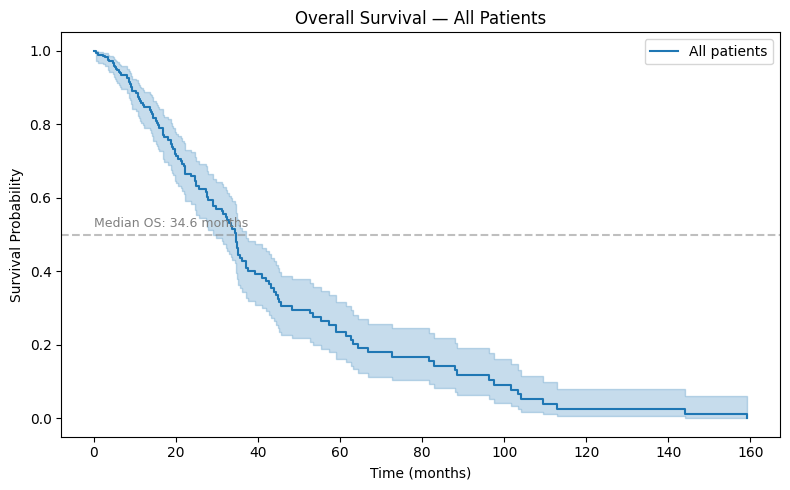

In [6]:
kmf = KaplanMeierFitter()

# ── 1. Overall survival curve ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
kmf.fit(df["months"], event_observed=df["event"], label="All patients")
kmf.plot_survival_function(ax=ax, ci_show=True)
ax.set_title("Overall Survival — All Patients")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
median_os = kmf.median_survival_time_
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5)
ax.text(0, 0.52, f"Median OS: {median_os:.1f} months", fontsize=9, color="grey")
plt.tight_layout()
plt.show()

In [7]:
kmf.event_table.head()

,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.000000,0,0,0,285,285
0.394218,1,1,0,0,285
0.459921,1,1,0,0,284
0.985545,1,1,0,0,283
1.609724,1,0,1,0,282


In [8]:
kmf.event_table.tail()

,removed,observed,censored,entrance,at_risk
event_at,,,,,
104.040736,1,1,0,0,5
109.395532,1,1,0,0,4
112.910644,1,1,0,0,3
144.152431,1,1,0,0,2
159.264126,1,1,0,0,1


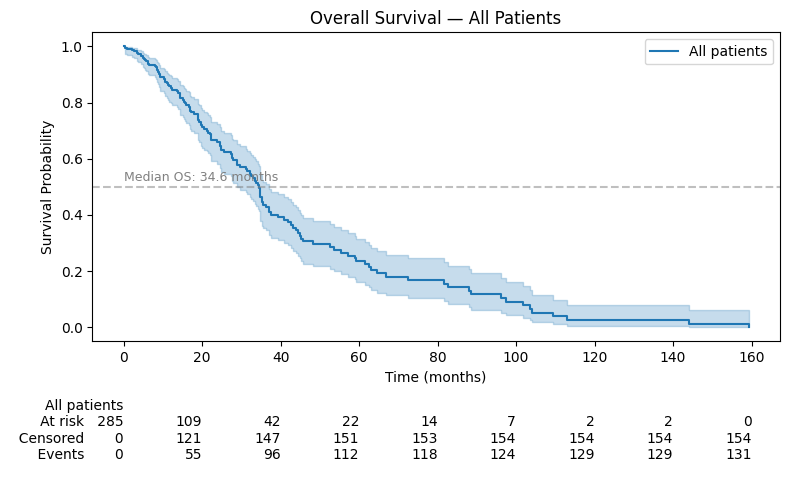

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
kmf.fit(df["months"], event_observed=df["event"], label="All patients")
kmf.plot_survival_function(ax=ax, ci_show=True, at_risk_counts=True)
ax.set_title("Overall Survival — All Patients")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
median_os = kmf.median_survival_time_
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5)
ax.text(0, 0.52, f"Median OS: {median_os:.1f} months", fontsize=9, color="grey")
plt.tight_layout()
plt.savefig(f"{PLOTS_PATH}/overall_survival_with_at_risk_counts.png", dpi=600)
plt.show()

In [10]:
t_cutoff = kmf.event_table.query("at_risk < 15").index.min()
t_cutoff = round(t_cutoff, 0)
t_cutoff

np.float64(82.0)

In [11]:
from lifelines.utils import restricted_mean_survival_time

rmst = restricted_mean_survival_time(kmf, t=t_cutoff)
rmst

np.float64(38.9599178983528)

In [12]:
def bootstrap_rmst(time, event, t, n_bootstraps=1000, ci=0.95, random_state=None):
    """
    Bootstrap the Restricted Mean Survival Time (RMST).

    Parameters
    ----------
    time : array-like
        Observed survival / follow-up times.
    event : array-like
        Event indicator (1 = event occurred, 0 = censored).
    t : float
        Restriction time horizon for the RMST.
    n_bootstraps : int
        Number of bootstrap resamples.
    ci : float
        Coverage of the confidence interval (default 0.95).
    random_state : int or None
        Seed for reproducibility.

    Returns
    -------
    dict with keys:
        rmst_observed  – RMST on the original data
        rmst_bootstrap – array of bootstrap RMST values
        ci_lower       – lower bound of the bootstrap percentile CI
        ci_upper       – upper bound of the bootstrap percentile CI
        se             – bootstrap standard error
    """
    rng = np.random.default_rng(random_state)
    time = np.asarray(time)
    event = np.asarray(event)
    n = len(time)

    # RMST on the original sample
    _kmf = KaplanMeierFitter()
    _kmf.fit(time, event_observed=event)
    rmst_obs = restricted_mean_survival_time(_kmf, t=t)

    # Bootstrap loop
    rmst_boot = np.empty(n_bootstraps)
    for i in range(n_bootstraps):
        idx = rng.integers(0, n, size=n)
        _kmf_b = KaplanMeierFitter()
        _kmf_b.fit(time[idx], event_observed=event[idx])
        rmst_boot[i] = restricted_mean_survival_time(_kmf_b, t=t)

    alpha = 1 - ci
    ci_lower = np.percentile(rmst_boot, 100 * alpha / 2)
    ci_upper = np.percentile(rmst_boot, 100 * (1 - alpha / 2))

    return {
        "rmst_observed": rmst_obs,
        "rmst_bootstrap": rmst_boot,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "se": rmst_boot.std(),
    }


In [13]:
result = bootstrap_rmst(df["months"], df["event"], t=t_cutoff, n_bootstraps=1000, random_state=42)

print(f"RMST (observed):  {result['rmst_observed']:.2f} months")
print(f"Bootstrap SE:     {result['se']:.2f} months")
print(f"95% CI:           [{result['ci_lower']:.2f}, {result['ci_upper']:.2f}] months")


RMST (observed):  38.96 months
Bootstrap SE:     2.08 months
95% CI:           [34.89, 43.02] months


In [14]:
df["months_trunc"] = df["months"].clip(upper=t_cutoff)
df["event_trunc"] = ((df["event"] == 1) & (df["months"] <= t_cutoff)).astype(int)

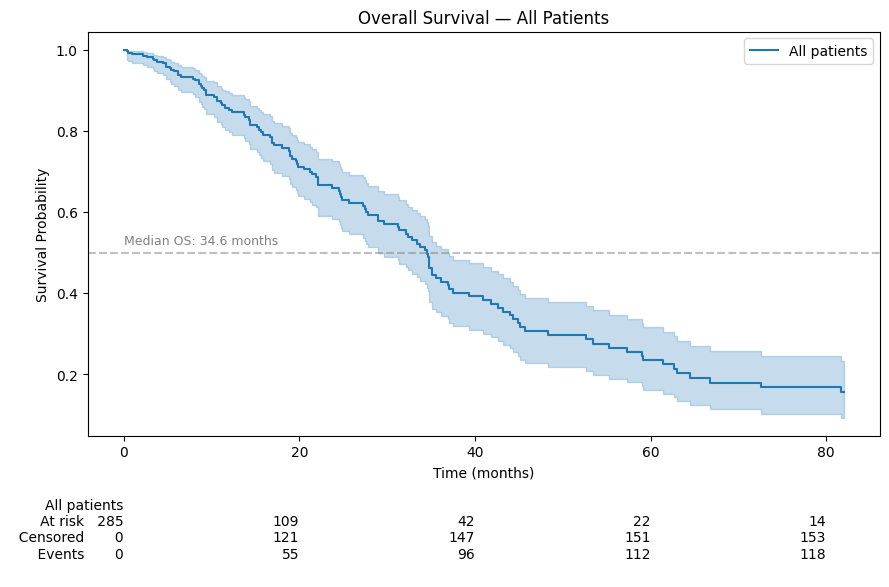

In [15]:
kmf_trunc = KaplanMeierFitter()
kmf_trunc.fit(df["months_trunc"], event_observed=df["event_trunc"], label="All patients")

fig, ax = plt.subplots(figsize=(9, 6))
kmf_trunc.plot_survival_function(ax=ax, ci_show=True, at_risk_counts=True)
ax.set_title("Overall Survival — All Patients")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
median_os = kmf_trunc.median_survival_time_
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5)
ax.text(0, 0.52, f"Median OS: {median_os:.1f} months", fontsize=9, color="grey")
plt.tight_layout()
plt.show()

In [16]:
df_reduc = df[~df["Tumor_grouped_Other"]].reset_index(drop=True)
df_reduc.shape

(264, 17)

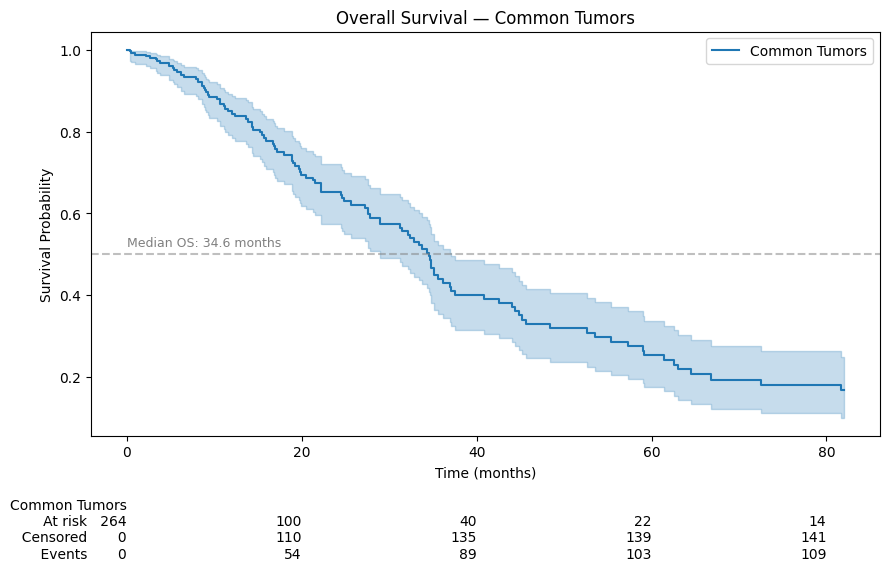

In [17]:
kmf_trunc = KaplanMeierFitter()
kmf_trunc.fit(df_reduc["months_trunc"], event_observed=df_reduc["event_trunc"], label="Common Tumors")

fig, ax = plt.subplots(figsize=(9, 6))
kmf_trunc.plot_survival_function(ax=ax, ci_show=True, at_risk_counts=True)
ax.set_title("Overall Survival — Common Tumors")
ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
median_os = kmf_trunc.median_survival_time_
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5)
ax.text(0, 0.52, f"Median OS: {median_os:.1f} months", fontsize=9, color="grey")
plt.tight_layout()
plt.savefig(f"{PLOTS_PATH}/overall_survival_common_tumors_with_at_risk_counts.png", dpi=600)
plt.show()

In [18]:
df_reduc.to_csv(f"{DATA_PATH}/GPT_processed_survival_data_truncated_common.csv", index=False)